# Categorical Variables

## Variable and Process
- Our data are **samples**
- Those samples of data are realizations of a **random variable**: A phenomenon occurs, and we observe some features or measurements of it
- Those samples are presumed to come from some **data generating process**; otherwise, the machine cannot learn any stable patterns
- The concept that connects these is the **random variable** and **expectation**: How do we expect the data generating process to behave? What can we learn about the random variable from the data we collect?

# 1. Binomial Variables

## Binomial Variables

- A binomial variable takes the values 0 or 1, depending on whether the underlying outcome took one category took one value (e.g. dead) or another (e.g alive)
- The random variable that takes labels into 0/1 values is called a **dummy variable**

## Example:

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns

df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')

df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


<Axes: xlabel='DEATH_EVENT', ylabel='Proportion'>

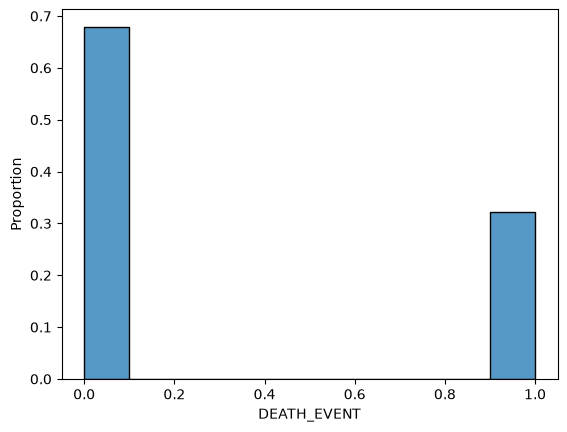

In [2]:
sns.histplot(data=df, x='DEATH_EVENT', stat='proportion')

In [3]:
SEM = np.sqrt( df['DEATH_EVENT'].var()/df.shape[0])
print(f'The standard error of the sample proportion is: {SEM:.3f}' )
df['DEATH_EVENT'].describe()

The standard error of the sample proportion is: 0.027


count    299.00000
mean       0.32107
std        0.46767
min        0.00000
25%        0.00000
50%        0.00000
75%        1.00000
max        1.00000
Name: DEATH_EVENT, dtype: float64

## The Bernoulli Trial and Dummy/Boolean Variables

- How do we model and analyze a variable like this?
- There are two possible outcomes: $H$ with probability $p$ and $T$ with probability $1-p$
- The random variable $I$ takes $I(H)=1$ for heads and $I(T)=0$ for tails
- We call $I$ an **indicator function** or **dummy variable** because it takes the values 0 and 1 depending on whether a condition is true (heads or tails)

<img src="./src/bernoulli.png" width="600px">

## Bernoulli Trials: Expectation and Variance
- What is the expectation of this random variable?
$$
\mathbb{E}[I] = p \times I(H) + (1-p) \times I(T) = p \times 1 + (1-p) \times 0 = p
$$
- Variance?
$$
\begin{alignat*}{2}
\mathbb{V}[I] &=& \mathbb{E}[ (I - \mathbb{E}[I])^2] \quad(\text{ Definition })\\
&=& p \times (1 - p)^2 + (1-p) \times ( 0 -p)^2 \quad(\text{ Expand defininition })\\
&=& p (1-p) (1-p +p ) \quad(\text{ Factor out $1-p$ })\\
&=& p(1-p) \quad(\text{ Simplify })
\end{alignat*}
$$
- For variables with binary outcomes like 0/1, the variance will very often include a term like "$p(1-p)$"

## Expectation of the Sample Proportion
- **How does a sample of Bernoulli variables behave?**
- Since the Bernoulli trial is 0/1-valued, the sample mean is the proportion of observations taking the value 1:
$$
\hat{p} = \frac{1}{n} \sum_{i=1}^n I_i, 
$$
where $I_i=1$ if observation $i$ takes the value 1, and $I_i = 0$ if observation $i$ takes the value 0

- What is the expectations of the sample average? With probability $p$, $I_i = 1$, and with probability $1-p$, $I_i = 0$, so linearity of the expectation implies
$$
\begin{alignat*}{2}
\mathbb{E}[ \hat{p} ] &=& \mathbb{E}\left[ \frac{1}{n} \sum_{i=1}^n I_i \right] \\
&=& \frac{1}{n} \sum_{i=1}^n \mathbb{E}\left[ I_i \right] \\
&=& \frac{1}{n} \sum_{i=1}^n \left( p \times 1 + (1-p) \times 0 \right) \\
&=& \frac{1}{n} \sum_{i=1}^n p \\
&=& p
\end{alignat*}
$$
- The expected value of our sample average $\hat{p}$ is equal to the true $p$, and we say that "$\hat{p}$ is an unbiased estimator of $p$"

## Categorical Variables/Multinomial Trials
- Imagine there are $L$ possible labels, $\ell_1, \ell_2, ..., \ell_L$
- For example, there are 4 car brands, Honda, Subaru, Ford, and Audi
- The **probability** of each label, $p_{1}, p_2, ..., p_L$ gives the proportion of the time that each label occurs
- Imagine we are interested in what will happen when, say, the next customer orders a car

## Indicator Variables
- For the Bernoulli Trial, we had the indicator labels $I(H) =1$ and $I(T)=0$
- When there is more than one label, we have to be more careful about tracking outcomes
- This concept plays a core role in probability: The **indicator function** of a categorical $C$ is
$$
\mathbb{I}\{ C = \ell \} = \begin{cases}
1, & L = \ell \\
0, & \text{ otherwise.}
\end{cases}
$$

## Sample Proportion

- How often does a particular label $\ell$ occur in a sample?
- The **sample proportion of label $\ell$** is
$$
\hat{p}_\ell = \dfrac{1}{N} \sum_{i=1}^N \mathbb{I} \{ c_i = \ell \}
$$

## Example: Patient Disease from NHAMCS

In [4]:
df = pd.read_csv('./data/ed_visits_probability_lab_train.csv')
df.head()

,sex,arrival_by_ambulance,disease_group,abdominal_pain,cough,vomiting,fever,nausea,chest_pain,shortness_of_breath,...,accident,dizziness,back_pain,anxiety,skin_rash,age_u20,age_20_40,age_40_60,age_60_70,age_o70
0,1,0,cardiovascular,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
1,1,0,injury_poisoning,1,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,1,0,dermatologic,0,1,0,0,0,0,0,...,0,0,0,0,1,1,0,0,0,0
3,0,0,other,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,injury_trauma,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


<Axes: xlabel='proportion', ylabel='disease_group'>

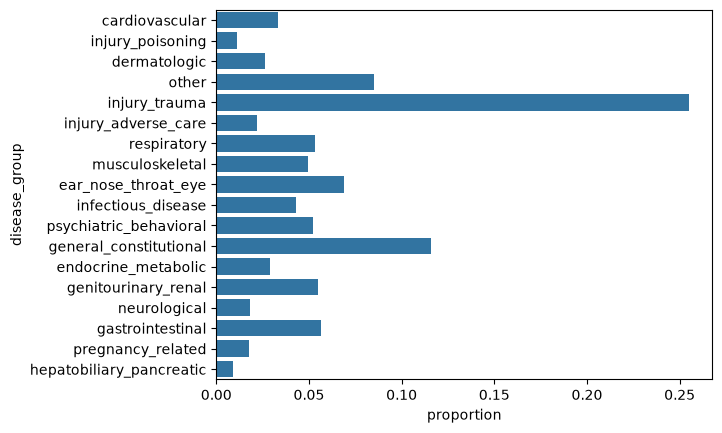

In [5]:
sns.countplot( y=df['disease_group'] , stat='proportion')

## Categoricals and One Hot Encoding
- When we create a full set of indicator functions for a labelled variable $C$, we are doing **one hot encoding**
    - For models with a bias or intercept, you'll typically `pd.get_dummies(df[var], dtype=int, drop_first=True)` in Pandas, to ensure your variables are not linearly dependent
    - In general, you can `pd.get_dummies(df[var], dtype=int)`

In [6]:
pd.get_dummies( df['disease_group'], dtype=int)

,cardiovascular,dermatologic,ear_nose_throat_eye,endocrine_metabolic,gastrointestinal,general_constitutional,genitourinary_renal,hepatobiliary_pancreatic,infectious_disease,injury_adverse_care,injury_poisoning,injury_trauma,musculoskeletal,neurological,other,pregnancy_related,psychiatric_behavioral,respiratory
0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69486,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
69487,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
69488,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
69489,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [7]:
pd.get_dummies( df['disease_group'], dtype=int).mean()

cardiovascular              0.033386
dermatologic                0.026061
ear_nose_throat_eye         0.069074
endocrine_metabolic         0.028953
gastrointestinal            0.056281
general_constitutional      0.115814
genitourinary_renal         0.054626
hepatobiliary_pancreatic    0.008893
infectious_disease          0.042998
injury_adverse_care         0.021744
injury_poisoning            0.011210
injury_trauma               0.254868
musculoskeletal             0.049359
neurological                0.018276
other                       0.085248
pregnancy_related           0.017801
psychiatric_behavioral      0.052338
respiratory                 0.053072
dtype: float64

## Properties of the Sample Dummies
- What happens when we take the expectation of the sample proportion?
$$
\begin{alignat*}{2}
\mathbb{E}\left[ \hat{p}_\ell \right] &=& \mathbb{E}\left[ \frac{1}{n} \sum_{i=1}^n \mathbb{I} \{ C_i = \ell\} \right]\\
&=& \frac{1}{n} \sum_{i=1}^n \mathbb{E}\left[ \mathbb{I} \{ C_i = \ell\} \right] \\
&=&  \frac{1}{n} \sum_{i=1}^n p_\ell \\
&=& = p_\ell
\end{alignat*}
$$
- Since the expectation of $\hat{p}_\ell$ is $p_\ell$, $\hat{p}_\ell$ is an **unbiased estimator** of $p_\ell$

# 2. Numeric Variables

## Analyzing Numeric Variables
- A **numeric variable** takes on number values:
    - Real values from $(-\infty, +\infty)$ represented on a computer as a `float`, like `3.14`
    - Integer values from $ ..., -3, -2, -1, 0, 1, 2, 3, ...$ represented on a computer as an `int`, like `25`
- The easiest way to understand what we do today is to ask the question, "How do we analyze numeric variables, as if they were categorical?"

## Visualizing Numeric Variables
- For categorical variables, every label occurs many times; for numeric data, a value might occur only once, and many values might be very sparse
- To see why plotting raw values like isn't helpful, consider the rugplot, `sns.rugplot()`

In [8]:
df = pd.read_csv('./data/heart_failure_clinical_records_dataset.csv')
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


[Text(0.5, 1.0, 'Rugplot: This is not very helpful')]

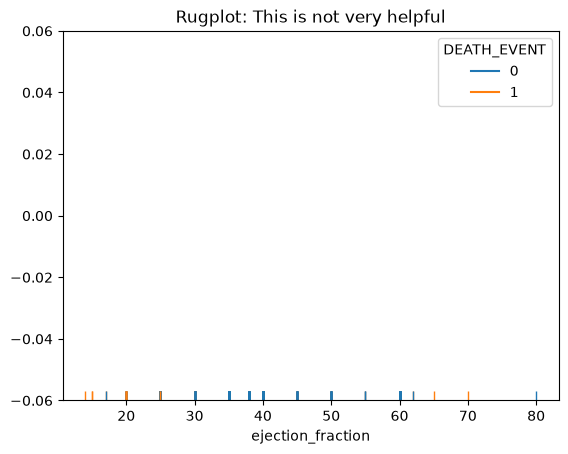

In [9]:
sns.rugplot( data=df, x= 'ejection_fraction', 
             hue = 'DEATH_EVENT').set(title='Rugplot: This is not very helpful')

## Indicator Functions

- Imagine we analyze the numeric **as if** it was a categorical, by sweeping a threshold back and forth, and asking "above or below the threshold?" for each observation
- Instead of asking if the value of the $i$-th observation $x_i$ takes a specific value $x$, we can ask, "Is observation $i$'s value, $x_i$, less than $x$?"
$$
\mathbb{I}\{x_i \le x\} = \begin{cases}
1, & x_i \le x\\
0, & \text{otherwise.}
\end{cases}
$$


<img src="./src/indicator.png" width="600px">

## The Empirical Cumulative Distribution Function

- Now take the sample mean over values $x_i$, and compute **the proportion of observations with values less than $x$**:
$$
\frac{1}{n} \sum_{i=1}^n \mathbb{I} \{x_i \le x\} = \hat{F}(x)
$$
- This is **like** a Bernoulli, where we're asking, "What proportion of the time is $x_i$ is less than $x$?" Or, "If we draw an observation at random, what proportion are above or below $x$?" 

<img src="./src/ecdf.png" width="600px">

## Example:

- Suppose your data are `[1, 2, 2, 3, 4, 4, 5]`
- What is the ECDF?

<Axes: xlabel='ejection_fraction', ylabel='Proportion'>

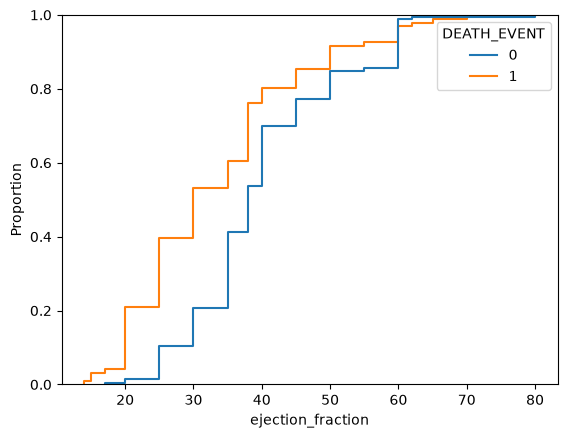

In [10]:
sns.ecdfplot( data=df, x='ejection_fraction', hue='DEATH_EVENT')

<Axes: xlabel='age', ylabel='Proportion'>

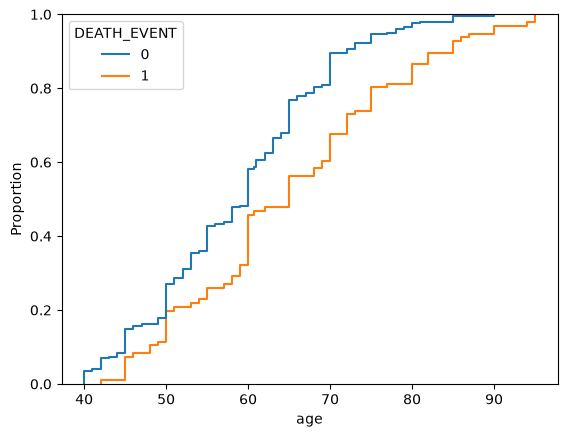

In [11]:
sns.ecdfplot( data=df, x='age', hue='DEATH_EVENT')

<Axes: xlabel='serum_sodium', ylabel='Proportion'>

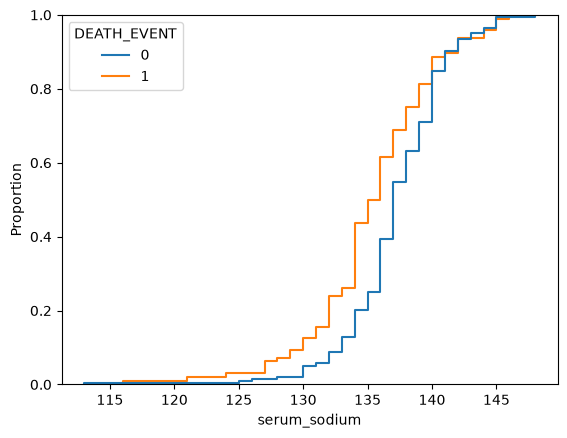

In [12]:
sns.ecdfplot( data=df, x='serum_sodium', hue='DEATH_EVENT')

## The ECDF
- Fix a value $x$. The proportion of the sample $[x_1, x_2, ..., x_n]$ less than $x$ is the function
$$
\hat{F}_n(x) = \dfrac{1}{n} \sum_{i=1}^n \mathbb{I}\{x_i \le x\}
$$
- This is called the **Empirical Cumulative Distribution Function**, and is one of our two main ways of modeling a numeric variable

## The ECDF
- The ECDF $\hat{F}_X(x)$...
    - must be non-decreasing: As we move $x$ to the right, we capture more observations
    - must be zero as $x$ gets very negative and 1 as $x$ gets very positive: Eventually, all of the sample is above or below the threshold $x$

# 3. The Cumulative Distribution Function

## What is the ECDF Estimating?

- Empirically, the ECDF asks, "What proportion of the data $[x_1, x_2, ..., x_n]$ are below a threshold, $x$?"
- The corresponding population level question is, "What is the probability that the random variable $X$ falls below a threshold, $x$?"
- We define this function as the **cumulative distribution function** or CDF:
$$
F(x) = p[X \le x] = p[ \{ s \text{ in the sample space, such that } X(s)\le x \}]
$$

## The Expected Sample Proportion of the ECDF at a Point
- What is the expected value of the ECDF?
$$
\begin{alignat*}{2}
\mathbb{E}[\hat{F}(x)] &=& \mathbb{E}_X \left[ \frac{1}{n} \sum_{i=1}^n \mathbb{I} \{ X_i \le x \} \right] \quad \left( \text{ Definition } \right) \\
&=&  \frac{1}{n} \sum_{i=1}^n \mathbb{E}_X \left[\mathbb{I} \{ X_i \le x \} \right] \quad \left( \text{Linearity} \right) \\
&=&   \frac{1}{n} \sum_{i=1}^n F(x) \quad \left( \text{Expectation of indicator is probability}\right) \\
&=&  F(x) \quad \left( \text{Sum of $n$ identical terms over $n$} \right)
\end{alignat*}
$$
- The ECDF $\hat{F}(x)$ is an unbiased estimator of the true CDF $F(x)$